# Modelado, comparación contra Vegas e interpretabilidad SHAP

Este notebook cubre el bloque de modelado del pipeline. Se apoya en la
tabla `master_v2.csv` generada por `dataset.ipynb` y en el fichero
`odds.csv` con las cuotas históricas. El proceso se estructura en cinco
etapas:

1. Preprocesado de las cuotas y cálculo de la probabilidad de Vegas sin
   *vig*, con la evaluación de su rendimiento como referencia.
2. Comparación de cuatro algoritmos de clasificación mediante validación
   temporal *walk-forward*.
3. Entrenamiento del modelo final XGBoost sobre el split 2018-2022.
4. Cruce de las predicciones con Vegas y análisis mes a mes y por
   discrepancia.
5. Interpretabilidad del modelo con valores SHAP y análisis caso a caso.

La salida final es el fichero `predicciones_modelo_split_test.csv` que
consume `bet.ipynb` para simular las estrategias de apuesta.

## 1. Referencia de Vegas: procesamiento de cuotas

Se cargan las cuotas históricas, se convierten las líneas americanas a
probabilidad implícita, se elimina el margen (*vig*) y se calcula la
*accuracy* global de Vegas como referencia contra la que comparar
cualquier modelo posterior.

=== RESUMEN GLOBAL ===
Partidos: 23085 | con moneyline: 19807 (86%)
Home win rate        : 0.581
Vig medio de la casa : 3.77%
Acierto Vegas (>0.5) : 0.684
Gana el favorito     : 0.684
Moneyline local      : min -13000, max 3000, mediana -170
AUC de Vegas: 0.7368

=== POR TEMPORADA ===
             n  con_ml  home_win   vig%  acc_vegas
season                                            
2008    1316.0   0.999     0.610  3.463      0.700
2009    1315.0   1.000     0.612  3.678      0.705
2010    1312.0   0.999     0.599  3.742      0.702
2011    1311.0   1.000     0.608  3.736      0.686
2012    1074.0   1.000     0.593  3.668      0.694
2013    1314.0   1.000     0.613  3.755      0.687
2014    1319.0   1.000     0.579  3.866      0.679
2015    1311.0   1.000     0.576  3.709      0.698
2016    1316.0   1.000     0.594  3.647      0.698
2017    1309.0   1.000     0.583  3.679      0.669
2018    1312.0   1.000     0.587  4.201      0.689
2019    1312.0   1.000     0.591  4.195      0.669


C:\Users\ignac\AppData\Local\Temp\ipykernel_29088\3999925034.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla = o.groupby('season').apply(resumen).round(3)


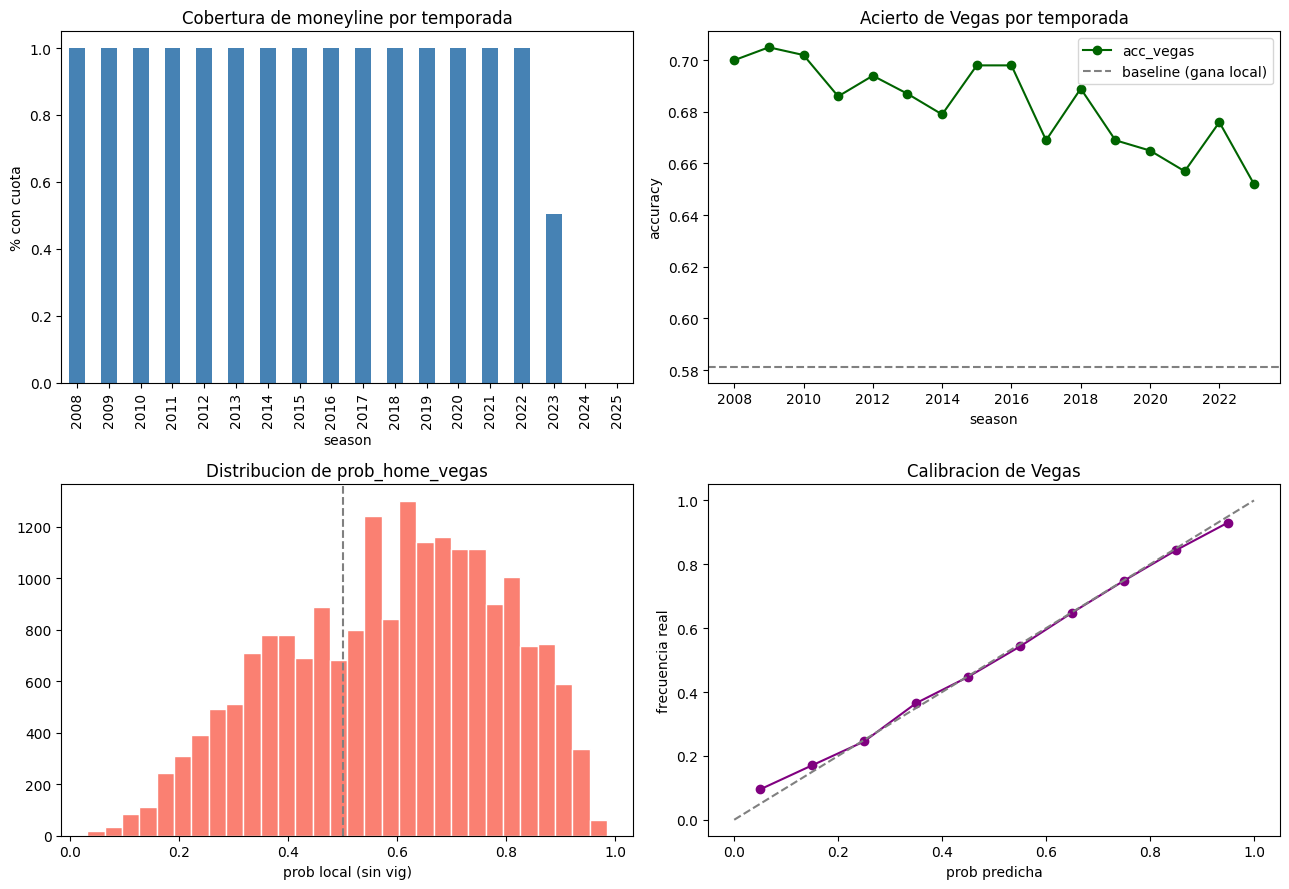

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

o = pd.read_csv('datasets/odds.csv')
o = o[o['regular'] | o['playoffs']]          # fuera pretemporada

def american_to_prob(ml):
    ml = pd.to_numeric(ml, errors='coerce')
    return np.where(ml < 0, -ml/(-ml+100), 100/(ml+100))

o['imp_home'] = american_to_prob(o['moneyline_home'])
o['imp_away'] = american_to_prob(o['moneyline_away'])
o['vig'] = o['imp_home'] + o['imp_away'] - 1
o['prob_home_vegas'] = o['imp_home'] / (o['imp_home'] + o['imp_away'])
o['home_win'] = (o['score_home'] > o['score_away']).astype(int)
o['has_ml'] = o['moneyline_home'].notna()

# ---------- Resumen global (solo partidos con moneyline) ----------
val = o[o['has_ml']]
fav_win = np.where(val['prob_home_vegas'] > 0.5, val['home_win'], 1 - val['home_win'])
print("=== RESUMEN GLOBAL ===")
print(f"Partidos: {len(o)} | con moneyline: {len(val)} ({len(val)/len(o):.0%})")
print(f"Home win rate        : {o['home_win'].mean():.3f}")
print(f"Vig medio de la casa : {val['vig'].mean()*100:.2f}%")
print(f"Acierto Vegas (>0.5) : {((val['prob_home_vegas']>0.5).astype(int)==val['home_win']).mean():.3f}")
print(f"Gana el favorito     : {fav_win.mean():.3f}")
print(f"Moneyline local      : min {val['moneyline_home'].min():.0f}, max {val['moneyline_home'].max():.0f}, mediana {val['moneyline_home'].median():.0f}")

# AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(val['home_win'], val['prob_home_vegas'])
print(f"AUC de Vegas: {auc:.4f}")
# ---------- Tabla por temporada ----------
def resumen(g):
    v = g[g['has_ml']]
    return pd.Series({
        'n': len(g),
        'con_ml': g['has_ml'].mean(),
        'home_win': g['home_win'].mean(),
        'vig%': v['vig'].mean()*100 if len(v) else np.nan,
        'acc_vegas': ((v['prob_home_vegas']>0.5).astype(int)==v['home_win']).mean() if len(v) else np.nan,
    })
tabla = o.groupby('season').apply(resumen).round(3)
print("\n=== POR TEMPORADA ===")
print(tabla)

# ---------- Graficos ----------
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

tabla['con_ml'].plot(kind='bar', ax=ax[0,0], color='steelblue')
ax[0,0].set_title('Cobertura de moneyline por temporada'); ax[0,0].set_ylabel('% con cuota')

tabla['acc_vegas'].dropna().plot(marker='o', ax=ax[0,1], color='darkgreen')
ax[0,1].axhline(o['home_win'].mean(), ls='--', color='gray', label='baseline (gana local)')
ax[0,1].set_title('Acierto de Vegas por temporada'); ax[0,1].set_ylabel('accuracy'); ax[0,1].legend()

ax[1,0].hist(val['prob_home_vegas'], bins=30, color='salmon', edgecolor='white')
ax[1,0].axvline(0.5, ls='--', color='gray')
ax[1,0].set_title('Distribucion de prob_home_vegas'); ax[1,0].set_xlabel('prob local (sin vig)')

bins = pd.cut(val['prob_home_vegas'], np.linspace(0, 1, 11))
cal = val.groupby(bins, observed=False)['home_win'].mean().dropna()
ax[1,1].plot([iv.mid for iv in cal.index], cal.values, marker='o', color='purple')
ax[1,1].plot([0,1],[0,1], ls='--', color='gray')
ax[1,1].set_title('Calibracion de Vegas'); ax[1,1].set_xlabel('prob predicha'); ax[1,1].set_ylabel('frecuencia real')

plt.tight_layout(); plt.show()

### Evolución del acierto de Vegas por temporada

Representación gráfica de la *accuracy* histórica de Vegas. Sirve para
identificar las temporadas donde el mercado ha sido más y menos preciso,
información útil para elegir la ventana temporal de test.

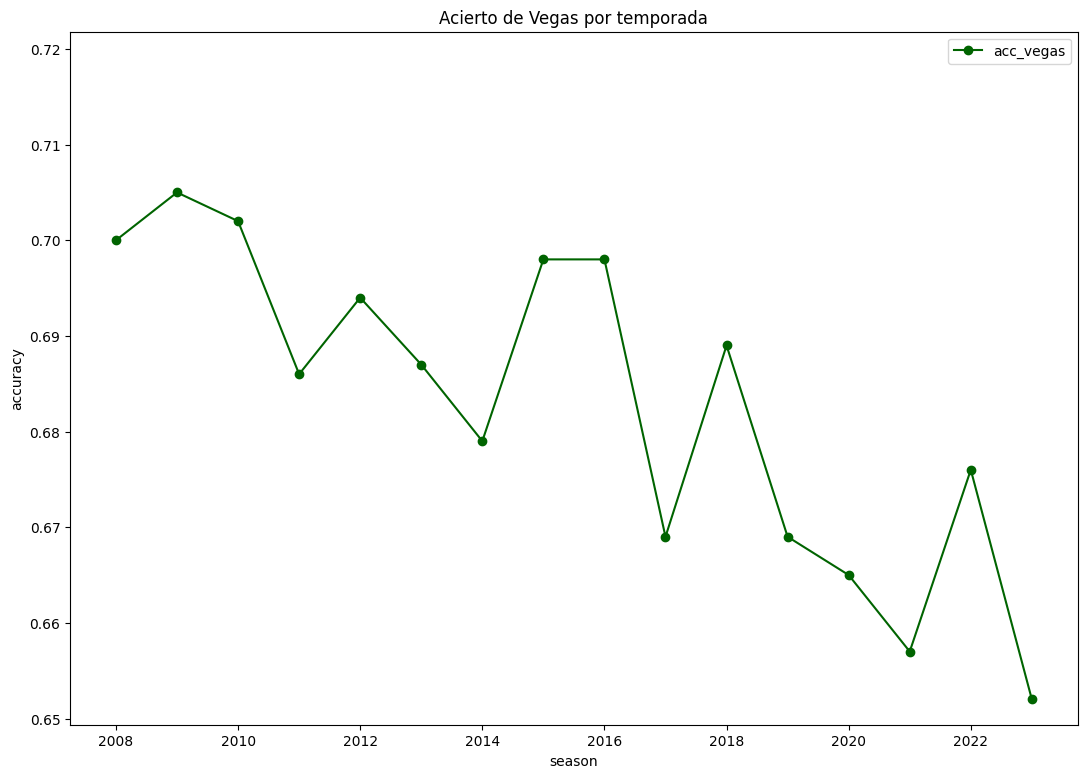

             n  con_ml  home_win   vig%  acc_vegas
season                                            
2008    1316.0   0.999     0.610  3.463      0.700
2009    1315.0   1.000     0.612  3.678      0.705
2010    1312.0   0.999     0.599  3.742      0.702
2011    1311.0   1.000     0.608  3.736      0.686
2012    1074.0   1.000     0.593  3.668      0.694
2013    1314.0   1.000     0.613  3.755      0.687
2014    1319.0   1.000     0.579  3.866      0.679
2015    1311.0   1.000     0.576  3.709      0.698
2016    1316.0   1.000     0.594  3.647      0.698
2017    1309.0   1.000     0.583  3.679      0.669
2018    1312.0   1.000     0.587  4.201      0.689
2019    1312.0   1.000     0.591  4.195      0.669
2020    1142.0   1.000     0.546  4.118      0.665
2021    1165.0   1.000     0.545  3.564      0.657
2022    1317.0   1.000     0.547  3.586      0.676
2023    1314.0   0.505     0.581  3.546      0.652
2024    1312.0   0.000     0.546    NaN        NaN
2025    1314.0   0.000     0.54

In [2]:
plt.figure(figsize=(13, 9))
tabla['acc_vegas'].dropna().plot(marker='o', color='darkgreen')

plt.title('Acierto de Vegas por temporada')
plt.ylabel('accuracy')
plt.legend()

# Forzar límites específicos
y_min, y_max = plt.ylim()
plt.ylim(y_min, y_max * 1.02)  # solo 2% extra arriba

plt.show()

print(tabla)

## 2. Comparación de cuatro algoritmos con *walk-forward*

Se comparan LogReg, Random Forest, XGBoost y HistGradientBoosting bajo
un esquema *walk-forward*, entrenando en cada iteración con todas las
temporadas anteriores y evaluando sobre la siguiente. El objetivo es
comprobar si algún algoritmo domina de forma consistente antes de fijar
el modelo definitivo.

In [55]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from xgboost import XGBClassifier

# ---------- Cargar master ----------
master = pd.read_csv('datasets/master_v2.csv', dtype={'GAME_ID': str})
master['GAME_DATE'] = pd.to_datetime(master['GAME_DATE'])

features = [c for c in master.columns if c.startswith('diff_')]
data = master.dropna(subset=features).sort_values('GAME_DATE').reset_index(drop=True)

# ---------- 4 modelos (instancias nuevas en cada split) ----------
def make_models():
    return {
        'LogReg':       make_pipeline(StandardScaler(),
                                      LogisticRegression(max_iter=1000)),
        'RandomForest': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
        'XGBoost':      XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                      subsample=0.8, eval_metric='logloss', random_state=42),
        'HistGB':       HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05,
                                                       max_iter=400, random_state=42),
    }

# ---------- 4 splits walk-forward: test = cada una de las ultimas 4 temporadas ----------
seasons = sorted(data['SEASON_YEAR'].unique())
test_seasons = seasons[-4:]

rows = []
for test_s in test_seasons:
    tr = data[data['SEASON_YEAR'] <  test_s]     # entreno con todo lo anterior
    te = data[data['SEASON_YEAR'] == test_s]     # testeo esa temporada
    for name, model in make_models().items():
        model.fit(tr[features], tr['home_team_won'])
        p = model.predict_proba(te[features])[:, 1]
        rows.append({'test': test_s, 'modelo': name, 'n_train': len(tr),
                     'acc': accuracy_score(te['home_team_won'], p > 0.5),
                     'auc': roc_auc_score(te['home_team_won'], p),
                     'logloss': log_loss(te['home_team_won'], p)})

res = pd.DataFrame(rows)
print(res.round(3).to_string(index=False))

print("\nAUC por modelo y split:")
print(res.pivot(index='modelo', columns='test', values='auc').round(3))

print("\nMedia de cada modelo a traves de los 4 splits:")
print(res.groupby('modelo')[['acc', 'auc', 'logloss']].mean().round(3).sort_values('auc', ascending=False))

   test       modelo  n_train   acc   auc  logloss
2019-20       LogReg    15252 0.631 0.698    0.628
2019-20 RandomForest    15252 0.655 0.691    0.639
2019-20      XGBoost    15252 0.659 0.697    0.635
2019-20       HistGB    15252 0.646 0.698    0.631
2020-21       LogReg    16295 0.642 0.700    0.632
2020-21 RandomForest    16295 0.636 0.692    0.640
2020-21      XGBoost    16295 0.633 0.689    0.641
2020-21       HistGB    16295 0.638 0.689    0.640
2021-22       LogReg    17359 0.643 0.703    0.632
2021-22 RandomForest    17359 0.651 0.696    0.638
2021-22      XGBoost    17359 0.660 0.706    0.630
2021-22       HistGB    17359 0.656 0.708    0.627
2022-23       LogReg    18573 0.638 0.671    0.639
2022-23 RandomForest    18573 0.632 0.656    0.645
2022-23      XGBoost    18573 0.638 0.675    0.638
2022-23       HistGB    18573 0.643 0.672    0.638

AUC por modelo y split:
test          2019-20  2020-21  2021-22  2022-23
modelo                                          
HistGB    

## 3. Modelo final: XGBoost regularizado

Entrenamiento del modelo definitivo con la configuración ganadora del
experimento de *tuning* (árboles poco profundos, regularización fuerte,
`learning_rate` alto compensado por menos árboles). Se entrena con todas
las temporadas anteriores a 2018-19 y se genera la probabilidad de
victoria del local sobre las temporadas 2018-2022.

In [56]:
import pandas as pd
from xgboost import XGBClassifier

master = pd.read_csv('datasets/master_v2.csv', dtype={'GAME_ID': str})
master['GAME_DATE'] = pd.to_datetime(master['GAME_DATE'])

features = [c for c in master.columns if c.startswith('diff_')]
if 'bubble' in master.columns and 'importance_max' in master.columns and 'importance_diff' in master.columns:
    print("Incluye features de burbuja e importancia.")
    features += ['bubble', 'importance_max', 'importance_diff']
data = master.dropna(subset=features).copy()
data['GAME_DATE'] = pd.to_datetime(data['GAME_DATE'])
data = data.sort_values('GAME_DATE').reset_index(drop=True)

# Predigo las ultimas temporadas CON cuotas; entreno solo con lo ANTERIOR
split = ['2018-19', '2019-20', '2020-21', '2021-22']
#split = ['2014-15','2015-16','2016-17','2017-18']
train = data[data['SEASON_YEAR'] < min(split)]      # <-- solo lo anterior, NO "todo menos"
test  = data[data['SEASON_YEAR'].isin(split)].copy()

model = XGBClassifier(n_estimators=300, max_depth=2, learning_rate=0.08,
          min_child_weight=15, gamma=0.5, reg_lambda=10)

model.fit(train[features], train['home_team_won'])

test['prob_home_win'] = model.predict_proba(test[features])[:, 1]

resultado = (test[['GAME_ID', 'GAME_DATE',
                   'home_TEAM_ABBREVIATION', 'away_TEAM_ABBREVIATION',
                   'prob_home_win', 'home_team_won']]
             .rename(columns={'home_TEAM_ABBREVIATION': 'home',
                              'away_TEAM_ABBREVIATION': 'away',
                              'home_team_won': 'resultado_real'})
             .reset_index(drop=True))

print(resultado.head(15))
print("Partidos con prediccion:", len(resultado))
print("auc:", roc_auc_score(resultado['resultado_real'], resultado['prob_home_win']))
print("accuracy:", accuracy_score(resultado['resultado_real'], resultado['prob_home_win'] > 0.5))
print("logloss:", log_loss(resultado['resultado_real'], resultado['prob_home_win']))

Incluye features de burbuja e importancia.
       GAME_ID  GAME_DATE home away  prob_home_win  resultado_real
0   0021800025 2018-10-19  LAC  OKC       0.552996               1
1   0021800024 2018-10-19  UTA  GSW       0.687644               0
2   0021800022 2018-10-19  NOP  SAC       0.906406               1
3   0021800021 2018-10-19  MIN  CLE       0.880003               1
4   0021800023 2018-10-19  MIL  IND       0.570950               1
5   0021800019 2018-10-19  TOR  BOS       0.761455               1
6   0021800018 2018-10-19  BKN  NYK       0.669519               1
7   0021800017 2018-10-19  ORL  CHA       0.448034               0
8   0021800020 2018-10-19  MEM  ATL       0.666867               1
9   0021800035 2018-10-20  LAL  HOU       0.367276               0
10  0021800026 2018-10-20  IND  BKN       0.804860               1
11  0021800027 2018-10-20  WAS  TOR       0.516245               0
12  0021800028 2018-10-20  NYK  BOS       0.243531               0
13  0021800029 2018

## 4. Cruce con Vegas y análisis contra el mercado

Se cargan las cuotas históricas, se calcula la probabilidad implícita
sin *vig* y se cruzan con las predicciones del modelo por fecha y
equipos. El resultado es un DataFrame con la probabilidad del modelo,
la de Vegas y el resultado real de cada partido.

In [57]:
import numpy as np
import pandas as pd

# 1) Cargar odds y calcular la prob REAL (sin vig) de la casa
odds = pd.read_csv('datasets/odds.csv')

def american_to_prob(ml):
    ml = pd.to_numeric(ml, errors='coerce')
    return np.where(ml < 0, -ml / (-ml + 100), 100 / (ml + 100))

ph = american_to_prob(odds['moneyline_home'])
pa = american_to_prob(odds['moneyline_away'])
odds['prob_home_vegas'] = ph / (ph + pa)
odds['date'] = pd.to_datetime(odds['date'])

# 2) Mapear abreviaturas de odds -> abreviaturas NBA (las de master/resultado)
odds2nba = {
    'atl':'ATL','bkn':'BKN','bos':'BOS','cha':'CHA','chi':'CHI','cle':'CLE',
    'dal':'DAL','den':'DEN','det':'DET','gs':'GSW','hou':'HOU','ind':'IND',
    'lac':'LAC','lal':'LAL','mem':'MEM','mia':'MIA','mil':'MIL','min':'MIN',
    'no':'NOP','ny':'NYK','okc':'OKC','orl':'ORL','phi':'PHI','phx':'PHX',
    'por':'POR','sac':'SAC','sa':'SAS','tor':'TOR','utah':'UTA','wsh':'WAS',
}
odds['home_abv'] = odds['home'].str.lower().map(odds2nba)
odds['away_abv'] = odds['away'].str.lower().map(odds2nba)

# Diagnostico: abreviaturas de odds que no estan en el diccionario
faltan = set(odds['home'].str.lower()) - set(odds2nba)
if faltan:
    print("OJO, abreviaturas sin mapear (anadelas a odds2nba):", faltan)

# 3) Cruzar con tus predicciones (resultado, de la celda del XGBoost) por fecha + equipos
res = resultado.copy()
res['date'] = pd.to_datetime(res['GAME_DATE'])
cruce = res.merge(odds[['date', 'home_abv', 'away_abv', 'prob_home_vegas']],
                  left_on=['date', 'home', 'away'],
                  right_on=['date', 'home_abv', 'away_abv'], how='inner')

# 4) df final (con el ganador real)
final = cruce[['date', 'home', 'away', 'prob_home_win', 'prob_home_vegas', 'resultado_real']].copy()
final['home_team_won'] = np.where(final['resultado_real'] == 1, final['home'], final['away'])
final = final.dropna(subset=['prob_home_vegas']).reset_index(drop=True)
print(f"Partidos cruzados: {len(final)} de {len(res)} predicciones")
final.head(15)

Partidos cruzados: 4535 de 4535 predicciones


,date,home,away,prob_home_win,prob_home_vegas,resultado_real,home_team_won
0,2018-10-19,LAC,OKC,0.552996,0.579832,1,LAC
1,2018-10-19,UTA,GSW,0.687644,0.447406,0,GSW
2,2018-10-19,NOP,SAC,0.906406,0.874142,1,NOP
3,2018-10-19,MIN,CLE,0.880003,0.778434,1,MIN
4,2018-10-19,MIL,IND,0.570950,0.603056,1,MIL
5,2018-10-19,TOR,BOS,0.761455,0.588212,1,TOR
6,2018-10-19,BKN,NYK,0.669519,0.609601,1,BKN
7,2018-10-19,ORL,CHA,0.448034,0.467532,0,CHA
8,2018-10-19,MEM,ATL,0.666867,0.714766,1,MEM
9,2018-10-20,LAL,HOU,0.367276,0.403727,0,HOU


### Partidos con mayor discrepancia entre modelo y Vegas

Selección de los partidos en los que la diferencia absoluta entre la
probabilidad del modelo y la de Vegas es mayor. Estos casos son
especialmente útiles para diagnosticar sesgos y sobreconfianza en el
modelo.

In [58]:
# Partidos donde mas difiere mi modelo de Vegas
final['diff_prob'] = final['prob_home_win'] - final['prob_home_vegas']   # + = soy mas optimista con el local que la casa
final['abs_diff']  = final['diff_prob'].abs()

top = final.sort_values('abs_diff', ascending=False).head(20).round(3)
print(top[['date', 'home', 'away', 'prob_home_win', 'prob_home_vegas', 'diff_prob', 'resultado_real']].to_string(index=False))

# Partidos con (|diff| > 0.3): quien acierta
disc = final[final['abs_diff'] > 0.3]
acc_modelo = ((disc['prob_home_win']   > 0.5).astype(int) == disc['resultado_real']).mean()
acc_vegas  = ((disc['prob_home_vegas'] > 0.5).astype(int) == disc['resultado_real']).mean()
print(f"\nPartidos con |diff| > 0.3: {len(disc)}")
print(f"Acierto modelo: {acc_modelo:.3f}  |  Acierto Vegas: {acc_vegas:.3f}")

      date home away  prob_home_win  prob_home_vegas  diff_prob  resultado_real
2021-11-09  PHI  MIL          0.775            0.285      0.490               0
2021-02-15  LAC  MIA          0.779            0.321      0.458               1
2018-12-28  LAL  LAC          0.654            0.274      0.379               0
2021-05-16  CHI  MIL          0.636            0.276      0.360               1
2020-01-03  WAS  POR          0.617            0.259      0.357               0
2021-01-27  ATL  BKN          0.672            0.327      0.345               0
2020-08-13  BOS  WAS          0.799            0.457      0.342               0
2021-02-07  NYK  MIA          0.661            0.321      0.340               0
2020-08-13  UTA  SAS          0.622            0.285      0.336               1
2022-03-08  CHA  BKN          0.724            0.388      0.336               0
2020-08-08  MIA  PHX          0.722            0.388      0.334               0
2021-11-12  SAS  DAL          0.757     

### Rendimiento mes a mes

Comparación de la *accuracy* del modelo y de Vegas desagregada por mes.
Permite ver en qué momentos del calendario el gap contra Vegas es
mayor, típicamente al inicio de temporada y en *playoffs*.

       n  acc_modelo  acc_vegas
mes                            
1    896       0.663      0.661
2    701       0.649      0.660
3    735       0.659      0.676
4    399       0.652      0.682
5    135       0.726      0.785
7      8       0.625      0.750
8     80       0.575      0.575
10   223       0.650      0.677
11   659       0.639      0.684
12   699       0.631      0.647
Partidos (sin burbuja): 4535
            acc    auc  logloss
Modelo    0.650  0.702    0.627
Vegas     0.669  0.726    0.606


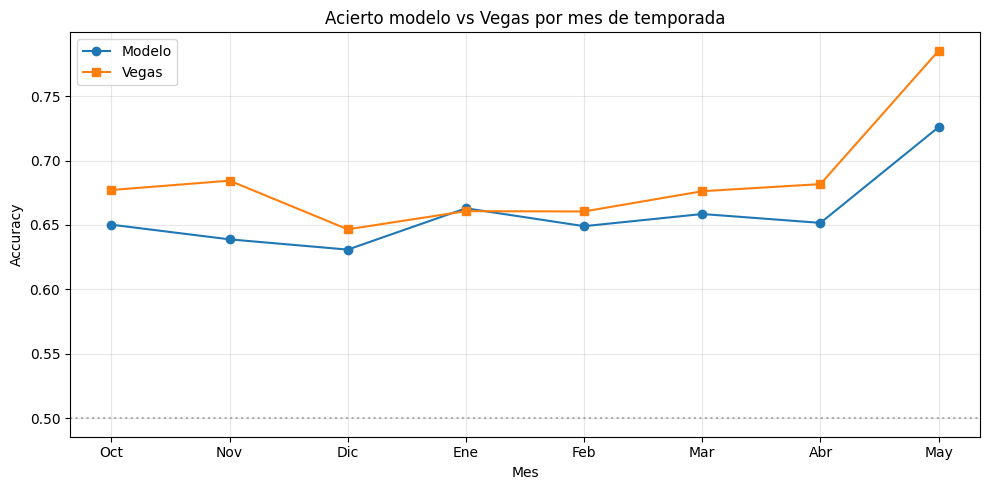

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

final['mes'] = final['date'].dt.month
final['ok_modelo'] = (final['prob_home_win'] > 0.5).astype(int) == final['resultado_real']
final['ok_vegas']  = (final['prob_home_vegas'] > 0.5).astype(int) == final['resultado_real']
print(final.groupby('mes').agg(n=('resultado_real','size'),
                               acc_modelo=('ok_modelo','mean'),
                               acc_vegas=('ok_vegas','mean')).round(3))

y = final['resultado_real']
# ---- Numero global ----
def met(p): return accuracy_score(y, p > 0.5), roc_auc_score(y, p), log_loss(y, p)
am, aucm, llm = met(final['prob_home_win'])
av, aucv, llv = met(final['prob_home_vegas'])
print(f"Partidos (sin burbuja): {len(final)}")
print(f"{'':8}{'acc':>7}{'auc':>7}{'logloss':>9}")
print(f"{'Modelo':8}{am:7.3f}{aucm:7.3f}{llm:9.3f}")
print(f"{'Vegas':8}{av:7.3f}{aucv:7.3f}{llv:9.3f}")

# ---- Grafico por mes (orden de temporada) ----
final['mes'] = final['date'].dt.month
final['ok_modelo'] = (final['prob_home_win']   > 0.5).astype(int) == final['resultado_real']
final['ok_vegas']  = (final['prob_home_vegas'] > 0.5).astype(int) == final['resultado_real']

orden = [10, 11, 12, 1, 2, 3, 4, 5, 6]
nombres = {10:'Oct',11:'Nov',12:'Dic',1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun'}
g = final.groupby('mes')[['ok_modelo', 'ok_vegas']].mean()
g = g.reindex([m for m in orden if m in g.index])

plt.figure(figsize=(10, 5))
plt.plot(range(len(g)), g['ok_modelo'], marker='o', label='Modelo')
plt.plot(range(len(g)), g['ok_vegas'],  marker='s', label='Vegas')
plt.xticks(range(len(g)), [nombres[m] for m in g.index])
plt.axhline(0.5, ls=':', color='gray', alpha=0.6)
plt.title('Acierto modelo vs Vegas por mes de temporada')
plt.ylabel('Accuracy'); plt.xlabel('Mes'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('modelo_vs_vegas_por_mes.png', dpi=150)   # para la memoria
plt.show()

## 5. Interpretabilidad con SHAP

Cálculo de los valores SHAP mediante la implementación nativa de XGBoost
(`pred_contribs=True`). Se produce el ranking global de importancia por
feature y los gráficos resumen que se incluyen en la memoria.

Top 20 features (importancia SHAP):
diff_players_pm_season        0.2154
diff_players_pie_season       0.1799
diff_players_netrtg_season    0.1330
diff_PIE_season               0.1061
diff_E_NET_RATING_season      0.0716
diff_E_NET_RATING_L10         0.0450
diff_STL_L5                   0.0439
diff_FG3A_L10                 0.0389
diff_PLUS_MINUS_season        0.0342
diff_OPP_PTS_FB_L5            0.0330
diff_players_netrtg_L10       0.0328
diff_NET_RATING_season        0.0309
diff_TOV_season               0.0298
diff_PTS_OFF_TOV_season       0.0281
diff_players_pie_L5           0.0220
diff_OPP_PTS_PAINT_season     0.0211
diff_FG3M_L10                 0.0202
diff_FGM_L10                  0.0199
importance_diff               0.0199
diff_STL_season               0.0195
dtype: float32


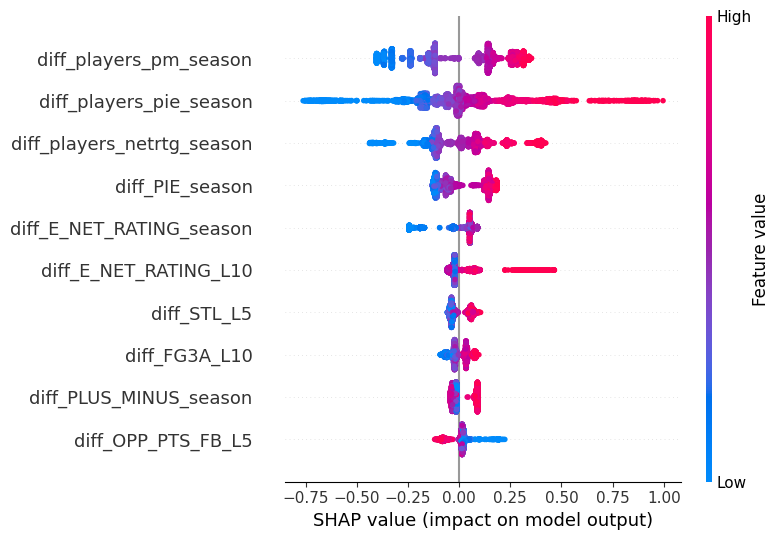

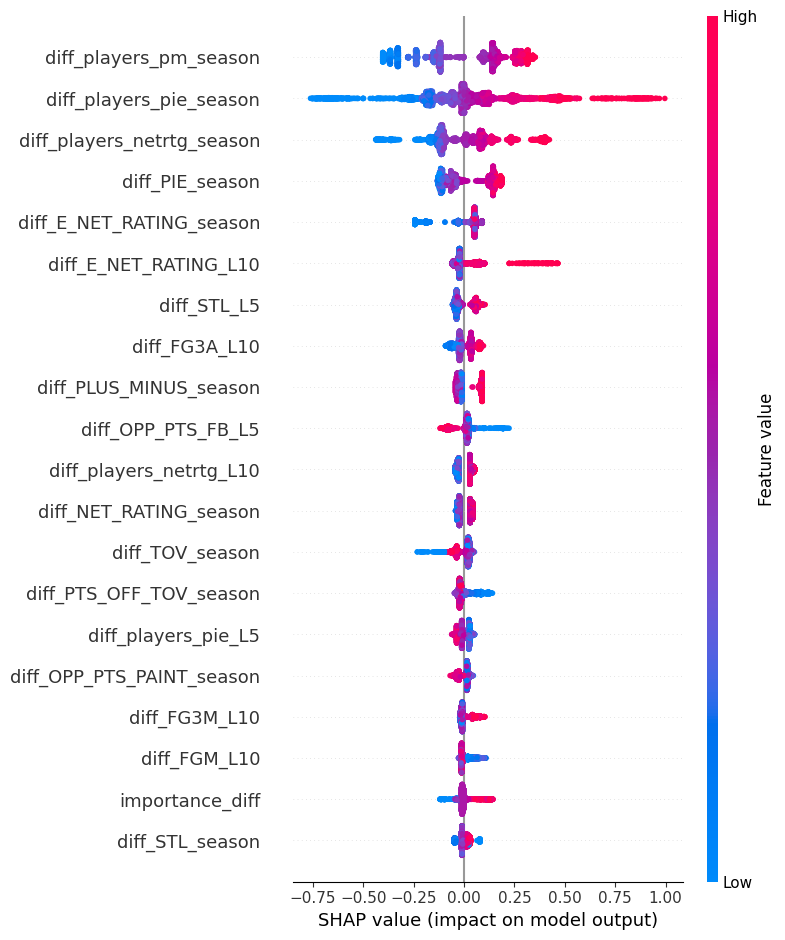


2021-11-09 PHI vs MIL  |  modelo=0.78  vegas=0.29  real=away
Top 10 features que mueven la prob (+ sube prob home, - la baja):
diff_players_pie_season      -0.259
diff_players_pm_season        0.206
diff_PIE_season               0.162
diff_players_netrtg_season    0.105
diff_PLUS_MINUS_season        0.078
diff_BLKA_L5                  0.075
diff_E_NET_RATING_L10         0.068
diff_FT_PCT_L10              -0.055
diff_E_NET_RATING_season      0.052
diff_BLK_season               0.050

2021-02-15 LAC vs MIA  |  modelo=0.78  vegas=0.32  real=home
Top 10 features que mueven la prob (+ sube prob home, - la baja):
diff_players_pie_season      -0.528
diff_players_pm_season        0.293
diff_four_factors_L10         0.195
diff_PIE_season               0.152
diff_players_netrtg_season    0.114
diff_E_OFF_RATING_L10         0.083
diff_E_NET_RATING_L10         0.083
diff_STL_L5                   0.080
diff_PLUS_MINUS_season        0.078
diff_E_DEF_RATING_L5          0.059

2018-12-28 LAL vs LAC  

In [63]:
import shap
import xgboost as xgb

# SHAP nativo de XGBoost (sortea el bug del parser)
dtest = xgb.DMatrix(test[features])
sv_full = model.get_booster().predict(dtest, pred_contribs=True)
shap_values = sv_full[:, :-1]    # la ultima columna es el bias (expected value), fuera

# Ranking global = media de |SHAP| por feature
shap_imp = (pd.Series(np.abs(shap_values).mean(axis=0), index=features)
              .sort_values(ascending=False))
print("Top 20 features (importancia SHAP):")
print(shap_imp.head(20).round(4))

# summary_plot solo necesita los valores y los datos, asi que sigue funcionando
shap.summary_plot(shap_values, test[features], max_display=10)
#shap.summary_plot(shap_values, test[features], max_display=20, plot_type='dot')
shap.summary_plot(shap_values, test[features])

# Top 5 partidos donde mas difiero de la casa
top_disc = final.sort_values('abs_diff', ascending=False).head(5)

# Para cruzar con test, hago match por fecha + abreviaturas
test_r = test.reset_index(drop=True).copy()
test_r['GAME_DATE'] = pd.to_datetime(test_r['GAME_DATE'])

for _, g in top_disc.iterrows():
    mask = ((test_r['GAME_DATE'] == g['date']) &
            (test_r['home_TEAM_ABBREVIATION'] == g['home']) &
            (test_r['away_TEAM_ABBREVIATION'] == g['away']))
    if not mask.any():
        continue
    i = test_r.index[mask][0]
    contribs = (pd.Series(shap_values[i], index=features)
                  .sort_values(key=np.abs, ascending=False))
    print(f"\n{g['date'].strftime('%Y-%m-%d')} {g['home']} vs {g['away']}  |  "
          f"modelo={g['prob_home_win']:.2f}  vegas={g['prob_home_vegas']:.2f}  "
          f"real={'home' if g['resultado_real']==1 else 'away'}")
    print("Top 10 features que mueven la prob (+ sube prob home, - la baja):")
    print(contribs.head(10).round(3).to_string())

## 6. Guardado de las predicciones

Se cruza el DataFrame de resultados con las cuotas para incorporar los
*moneylines* originales y se guarda el fichero
`predicciones_modelo_split_test.csv`. Este es el archivo que consume
`bet.ipynb` para simular las estrategias de apuesta.

=== Partidos con |diff|>0.3: 14 ===
Modelo apuesta LOCAL en 93% de los casos
Vegas  apuesta LOCAL en 0% de los casos
En realidad gana LOCAL  en 29% de los casos

Aciertos: modelo 21%, vegas 71%
Confianza media del modelo en sus picks: 0.69

--- Por mes ---
     n  modelo  vegas
mes                  
1    2    0.00   1.00
2    2    0.50   0.50
3    1    0.00   1.00
5    1    1.00   0.00
8    3    0.33   0.67
11   4    0.00   0.75
12   1    0.00   1.00

--- En los 11 fallos del modelo ---
  Apostaba LOCAL: 91%
  Confianza media: 0.69
  Concentracion en octubre+noviembre+agosto(burbuja): 55%


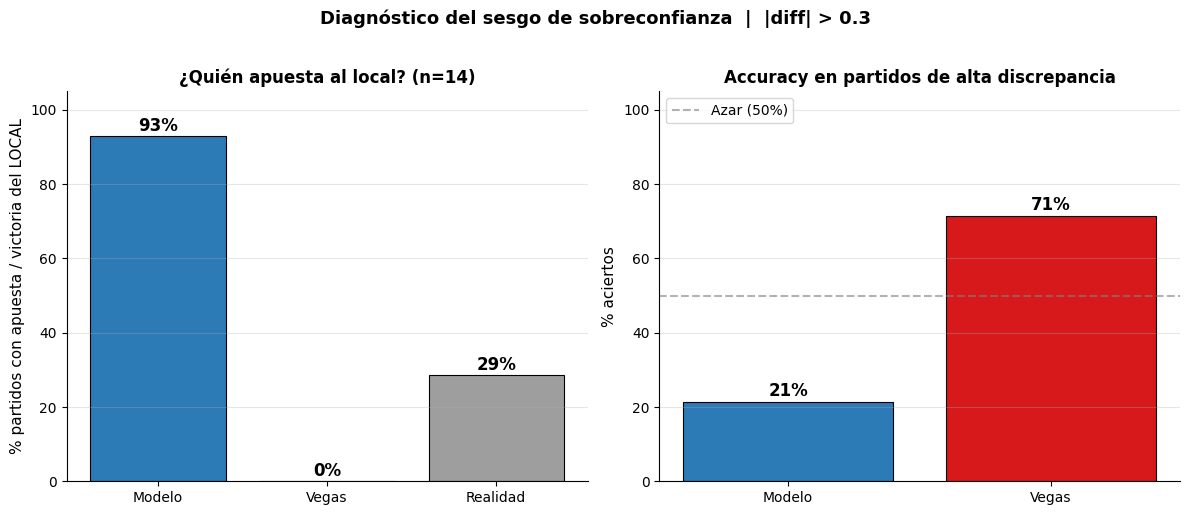

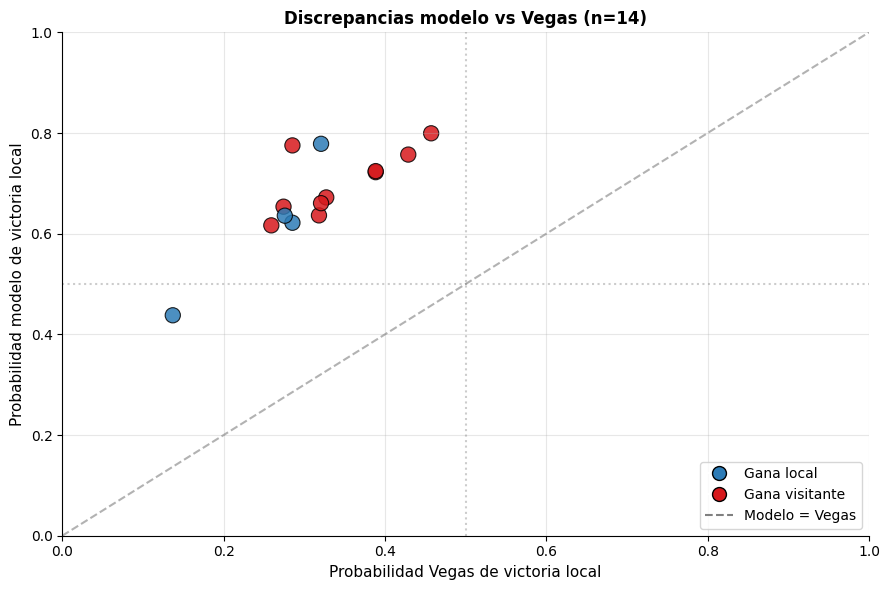

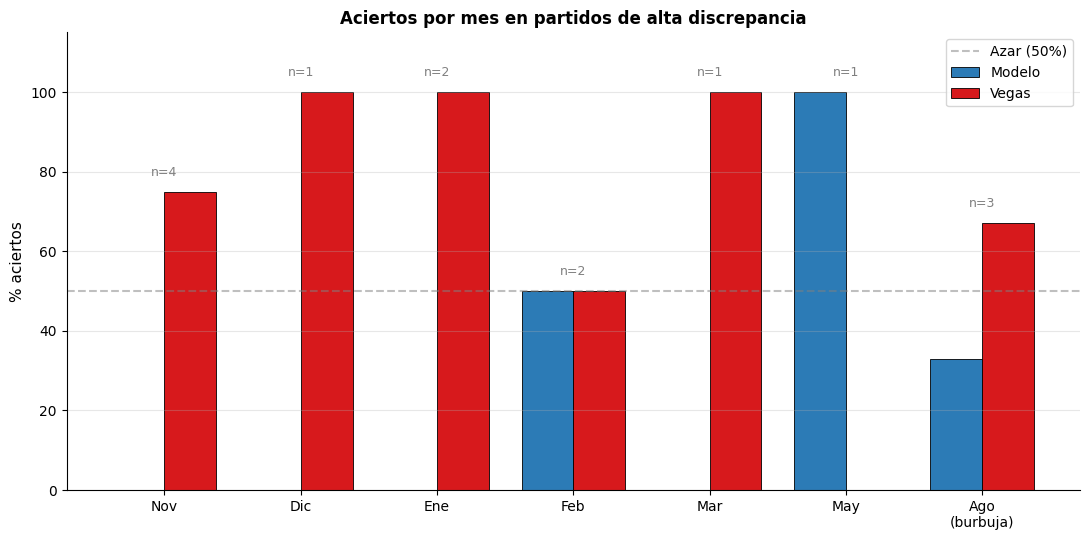

In [ ]:
disc = final[final['abs_diff'] > 0.3].copy()
disc['date'] = pd.to_datetime(disc['date'])
disc['mes'] = disc['date'].dt.month
disc['model_pick']    = np.where(disc['prob_home_win'] > 0.5, 'home', 'away')
disc['vegas_pick']    = np.where(disc['prob_home_vegas'] > 0.5, 'home', 'away')
disc['actual']        = np.where(disc['resultado_real'] == 1, 'home', 'away')
disc['model_correct'] = disc['model_pick'] == disc['actual']
disc['vegas_correct'] = disc['vegas_pick'] == disc['actual']
disc['confianza']     = np.where(disc['model_pick']=='home',
                              disc['prob_home_win'], 1 - disc['prob_home_win'])

print(f"=== Partidos con |diff|>0.3: {len(disc)} ===")
print(f"Modelo apuesta LOCAL en {(disc['model_pick']=='home').mean():.0%} de los casos")
print(f"Vegas  apuesta LOCAL en {(disc['vegas_pick']=='home').mean():.0%} de los casos")
print(f"En realidad gana LOCAL  en {(disc['actual']=='home').mean():.0%} de los casos")
print(f"\nAciertos: modelo {disc['model_correct'].mean():.0%}, vegas {disc['vegas_correct'].mean():.0%}")
print(f"Confianza media del modelo en sus picks: {disc['confianza'].mean():.2f}")
print("\n--- Por mes ---")
print(disc.groupby('mes').agg(n=('model_correct','size'),
                              modelo=('model_correct','mean'),
                              vegas =('vegas_correct','mean')).round(2))

# La pregunta clave: cuando me equivoco mucho, ¿es por sobreconfianza en el LOCAL?
fail = disc[~disc['model_correct']]
print(f"\n--- En los {len(fail)} fallos del modelo ---")
print(f"  Apostaba LOCAL: {(fail['model_pick']=='home').mean():.0%}")
print(f"  Confianza media: {fail['confianza'].mean():.2f}")
print(f"  Concentracion en octubre+noviembre+agosto(burbuja): "
      f"{fail['mes'].isin([8,10,11]).mean():.0%}")

por_mes = disc.groupby('mes').agg(
    n=('model_correct','size'),
    modelo=('model_correct','mean'),
    vegas=('vegas_correct','mean')
).round(2)

# Ordeno en orden de temporada NBA (oct-nov-...-may + agosto burbuja)
orden_meses = [10, 11, 12, 1, 2, 3, 4, 5, 6, 8]
nombres = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
           8:'Ago\n(burbuja)', 10:'Oct', 11:'Nov', 12:'Dic'}
por_mes = por_mes.reindex([m for m in orden_meses if m in por_mes.index])

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(por_mes))
ancho = 0.38
ax.bar(x - ancho/2, por_mes['modelo']*100, ancho,
       label='Modelo', color='#2C7BB6', edgecolor='black', linewidth=0.6)
ax.bar(x + ancho/2, por_mes['vegas']*100, ancho,
       label='Vegas', color='#D7191C', edgecolor='black', linewidth=0.6)

# Anotaciones con n encima
for i, (idx, row) in enumerate(por_mes.iterrows()):
    ax.text(i, max(row['modelo']*100, row['vegas']*100) + 4,
            f'n={int(row["n"])}', ha='center', fontsize=9, color='gray')

ax.axhline(50, ls='--', color='gray', alpha=0.5, label='Azar (50%)')
ax.set_xticks(x)
ax.set_xticklabels([nombres[m] for m in por_mes.index])
ax.set_ylabel('% aciertos', fontsize=11)
ax.set_title('Aciertos por mes en partidos de alta discrepancia',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 115)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('sobreconfianza_por_mes.png', dpi=150, bbox_inches='tight')
plt.show()

In [62]:
import pandas as pd

# Cruzo resultado con odds para traer los moneylines
res = resultado.copy()
res['date'] = pd.to_datetime(res['GAME_DATE'])

cruce = res.merge(
    odds[['date', 'home_abv', 'away_abv', 'moneyline_home', 'moneyline_away']],
    left_on=['date', 'home', 'away'],
    right_on=['date', 'home_abv', 'away_abv'],
    how='inner'
)

# Selecciono y renombro para el CSV final
out = (cruce[['GAME_ID', 'GAME_DATE', 'home', 'away', 'prob_home_win',
              'resultado_real', 'moneyline_home', 'moneyline_away']]
       .rename(columns={'home': 'home_abv',
                        'away': 'away_abv',
                        'resultado_real': 'home_team_won'}))

out.to_csv('datasets/predicciones_modelo_split_test.csv', index=False)
print(f"Guardado: {len(out)} partidos")
print(out.head(10))

Guardado: 4535 partidos
      GAME_ID  GAME_DATE home_abv away_abv  prob_home_win  home_team_won  \
0  0021800025 2018-10-19      LAC      OKC       0.552996              1   
1  0021800024 2018-10-19      UTA      GSW       0.687644              0   
2  0021800022 2018-10-19      NOP      SAC       0.906406              1   
3  0021800021 2018-10-19      MIN      CLE       0.880003              1   
4  0021800023 2018-10-19      MIL      IND       0.570950              1   
5  0021800019 2018-10-19      TOR      BOS       0.761455              1   
6  0021800018 2018-10-19      BKN      NYK       0.669519              1   
7  0021800017 2018-10-19      ORL      CHA       0.448034              0   
8  0021800020 2018-10-19      MEM      ATL       0.666867              1   
9  0021800035 2018-10-20      LAL      HOU       0.367276              0   

   moneyline_home  moneyline_away  
0          -150.0           130.0  
1           115.0          -135.0  
2         -1000.0           664